In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from numpy.random import default_rng

seed = 42
rng = default_rng(42)

from matplotlib.font_manager import FontProperties

font = FontProperties()
font.set_family("serif")
font.set_name("DejaVu Sans")

In [2]:
def plot_posterior_binary(G_dim, disrupting_pattern_indices, all_idata):
    """
    Modified function to plot bar plots of MEI, Completing, and Disrupting patterns for binary X
    in the same subplot for each latent variable G.

    Parameters:
    - G_dim (int): Dimension of the latent variable G.
    - disrupting_pattern_indices (list): List of indices corresponding to disrupting patterns.
    - all_idata (list): List containing InferenceData objects for MEI, Completing, and Disrupting 1 and Disrupting 2 patterns.

    Returns:
    - fig (matplotlib.figure.Figure): The Matplotlib figure object containing the generated plot.
    - axs (numpy.ndarray): 2D array of Matplotlib axes objects representing subplots in the figure.
    - completing_perc_diff_list (list): List of percentage differences for Completing.
    - disrupting_1_perc_diff_list (list): List of percentage differences for Disrupting 1.
    - disrupting_2_perc_diff_list (list): List of percentage differences for Disrupting 2.
    """

    fig, axs = plt.subplots(
        G_dim, 6, figsize=(6 * 8, 3 * 4), tight_layout=True, sharex="col", sharey="row"
    )
    legend_size = 6

    completing_perc_diff_list = []
    disrupting_1_perc_diff_list = []
    disrupting_2_perc_diff_list = []

    for idx, (ax_set, idata_set, disrupting_pattern_idx) in enumerate(
        zip(axs, all_idata, disrupting_pattern_indices)
    ):
        center_x_id = 4 * G_dim + idx

        # Collect probabilities for MEI, Completing, and Disrupting patterns
        center_probabilities = []
        all_probabilities = []
        for pattern_id, idata in enumerate(idata_set):
            x_prob = idata["posterior"]["X"].data[:, :, center_x_id].mean()
            center_probabilities.append(x_prob)
            all_x_prob = idata["posterior"]["X"].data.mean(axis=0).mean(axis=0)
            all_probabilities.append(all_x_prob)

            if pattern_id == 0:
                mei_x_prob = x_prob
            elif pattern_id > 0:
                perc_diff = (x_prob - mei_x_prob) / mei_x_prob * 100
                if pattern_id == 1:
                    completing_perc_diff_list.append(perc_diff)
                elif pattern_id == 2:
                    disrupting_1_perc_diff_list.append(perc_diff)
                elif pattern_id == 3:
                    disrupting_2_perc_diff_list.append(perc_diff)
            # if idx == 3:
            #     print(idata["posterior"]["X"].data[:, :, center_x_id])
            #     print(center_probabilities)

        # Plot center_probabilities in the same subplot for comparison
        ax_set[0].bar(
            ["MEI", "Completing", "Disrupting 1", "Disrupting 2"],
            center_probabilities,
            color=["blue", "green", "orange", "red"],
        )
        ax_set[0].set_ylim(0, 1)  # Probabilities range from 0 to 1

        # Plot all_probabilities in the same subplot for comparison
        for idx, probs in enumerate(all_probabilities):
            ax_set[2 + idx].bar(
                list(range(G_dim * 9)),
                probs,
                color=["red" if i == center_x_id else "blue" for i in range(G_dim * 9)],
            )
            ax_set[2 + idx].set_xticks(list(range(G_dim * 9)))
            ax_set[2 + idx].set_xticklabels(list(range(G_dim * 9)))

        # Plot G distributions (unchanged)
        mei_g_samples = idata_set[0]["posterior"]["G"].data.mean(axis=0).mean(axis=0)
        completing_g_samples = (
            idata_set[1]["posterior"]["G"].data.mean(axis=0).mean(axis=0)
        )
        disrupting_1_g_samples = (
            idata_set[2]["posterior"]["G"].data.mean(axis=0).mean(axis=0)
        )
        disrupting_2_g_samples = (
            idata_set[3]["posterior"]["G"].data.mean(axis=0).mean(axis=0)
        )

        ax_set[1].bar(x=np.arange(G_dim), height=mei_g_samples, width=0.8, color="blue")
        ax_set[1].bar(
            x=np.arange(G_dim) + G_dim,
            height=completing_g_samples,
            width=0.8,
            color="green",
        )
        ax_set[1].bar(
            x=np.arange(G_dim) + G_dim * 2,
            height=disrupting_1_g_samples,
            width=0.8,
            color="orange",
        )
        ax_set[1].bar(
            x=np.arange(G_dim) + G_dim * 3,
            height=disrupting_2_g_samples,
            width=0.8,
            color="red",
        )
        ax_set[1].set_xticks(np.arange(G_dim * 4))
        ax_set[1].set_xticklabels(list(np.arange(G_dim)) * 4)

    completing_perc_diff_list = np.array(completing_perc_diff_list)
    disrupting_1_perc_diff_list = np.array(disrupting_1_perc_diff_list)
    disrupting_2_perc_diff_list = np.array(disrupting_2_perc_diff_list)

    return (
        fig,
        axs,
        completing_perc_diff_list,
        disrupting_1_perc_diff_list,
        disrupting_2_perc_diff_list,
    )

In [3]:
with open("results_10.pkl", "rb") as f:
    all_idata, G_dim, disrupting_pattern_indices = pickle.load(f)

In [4]:
# (
#     fig,
#     axs,
#     completing_perc_diff_list,
#     disrupting_1_perc_diff_list,
#     disrupting_2_perc_diff_list,
# ) = plot_posterior_binary(G_dim, disrupting_pattern_indices, all_idata)

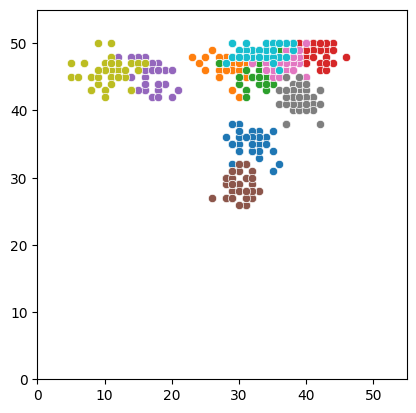

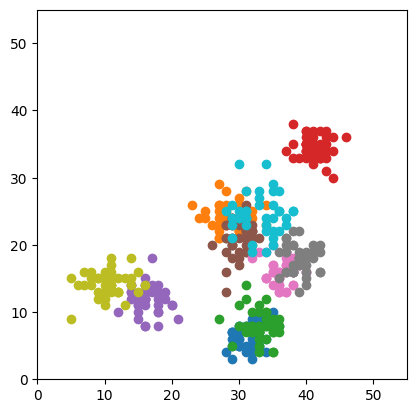

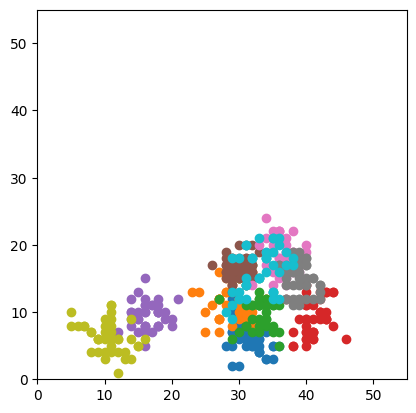

In [5]:
# colors = plt.cm.tab10(range(len(all_idata)))
# fig, axs = plt.subplots(nrows=1, ncols=3, dpi=300, sharey=True, tight_layout=True)
fig_exc, ax_exc = plt.subplots()
fig_dis1, ax_dis1 = plt.subplots()
fig_dis2, ax_dis2 = plt.subplots()
mei_rates = []
completing_rates = []
disrupting_1_rates = []
disrupting_2_rates = []
for idx, (idata_set, disrupting_pattern_idx) in enumerate(
    zip(all_idata, disrupting_pattern_indices)
):
    center_x_id = 4 * G_dim + idx

    # idata['posterior']['X'].data.shape = (n_chains, n_samples, n_x_dims)
    mei_firing_rates = (
        idata_set[0].posterior.X.data[:, :, center_x_id].reshape(50, 40).sum(axis=0)
    )
    mei_rates.append(mei_firing_rates)
    completing_firing_rates = (
        idata_set[1].posterior.X.data[:, :, center_x_id].reshape(50, 40).sum(axis=0)
    )
    completing_rates.append(completing_firing_rates)
    disrupting_1_firing_rates = (
        idata_set[2].posterior.X.data[:, :, center_x_id].reshape(50, 40).sum(axis=0)
    )
    disrupting_1_rates.append(disrupting_1_firing_rates)
    disrupting_2_firing_rates = (
        idata_set[3].posterior.X.data[:, :, center_x_id].reshape(50, 40).sum(axis=0)
    )
    disrupting_2_rates.append(disrupting_2_firing_rates)
    sns.scatterplot(x=mei_firing_rates, y=completing_firing_rates, ax=ax_exc)
    # ax_exc.scatter(mei_firing_rates, completing_firing_rates)
    ax_exc.set_xlim(0, 55)
    ax_exc.set_ylim(0, 55)
    # make square
    ax_exc.set_box_aspect(1)

    ax_dis1.scatter(mei_firing_rates, disrupting_1_firing_rates)
    ax_dis1.set_xlim(0, 55)
    ax_dis1.set_ylim(0, 55)
    # make square
    ax_dis1.set_box_aspect(1)

    ax_dis2.scatter(mei_firing_rates, disrupting_2_firing_rates)
    ax_dis2.set_xlim(0, 55)
    ax_dis2.set_ylim(0, 55)
    # make square
    ax_dis2.set_box_aspect(1)

In [6]:
mei_rates = np.array(mei_rates)
completing_rates = np.array(completing_rates)
disrupting_1_rates = np.array(disrupting_1_rates)
disrupting_2_rates = np.array(disrupting_2_rates)

In [7]:
print(mei_rates.shape)
print(completing_rates.shape)
print(disrupting_1_rates.shape)
print(disrupting_2_rates.shape)

(10, 40)
(10, 40)
(10, 40)
(10, 40)


In [8]:
all_mei_means = mei_rates.mean(axis=1)
all_completing_means = completing_rates.mean(axis=1)
all_disrupting_1_means = disrupting_1_rates.mean(axis=1)
all_disrupting_2_means = disrupting_2_rates.mean(axis=1)

In [9]:
all_mei_rates = mei_rates.flatten()
all_completing_rates = completing_rates.flatten()
all_disrupting_1_rates = disrupting_1_rates.flatten()

all_disrupting_2_rates = disrupting_2_rates.flatten()

In [53]:
xlim = 55
ylim = 55
last_xtick = 50
last_ytick = 50
noise = 1
dot_size = 10
dot_alpha = 0.30
star_size = 120
labelsize = 20

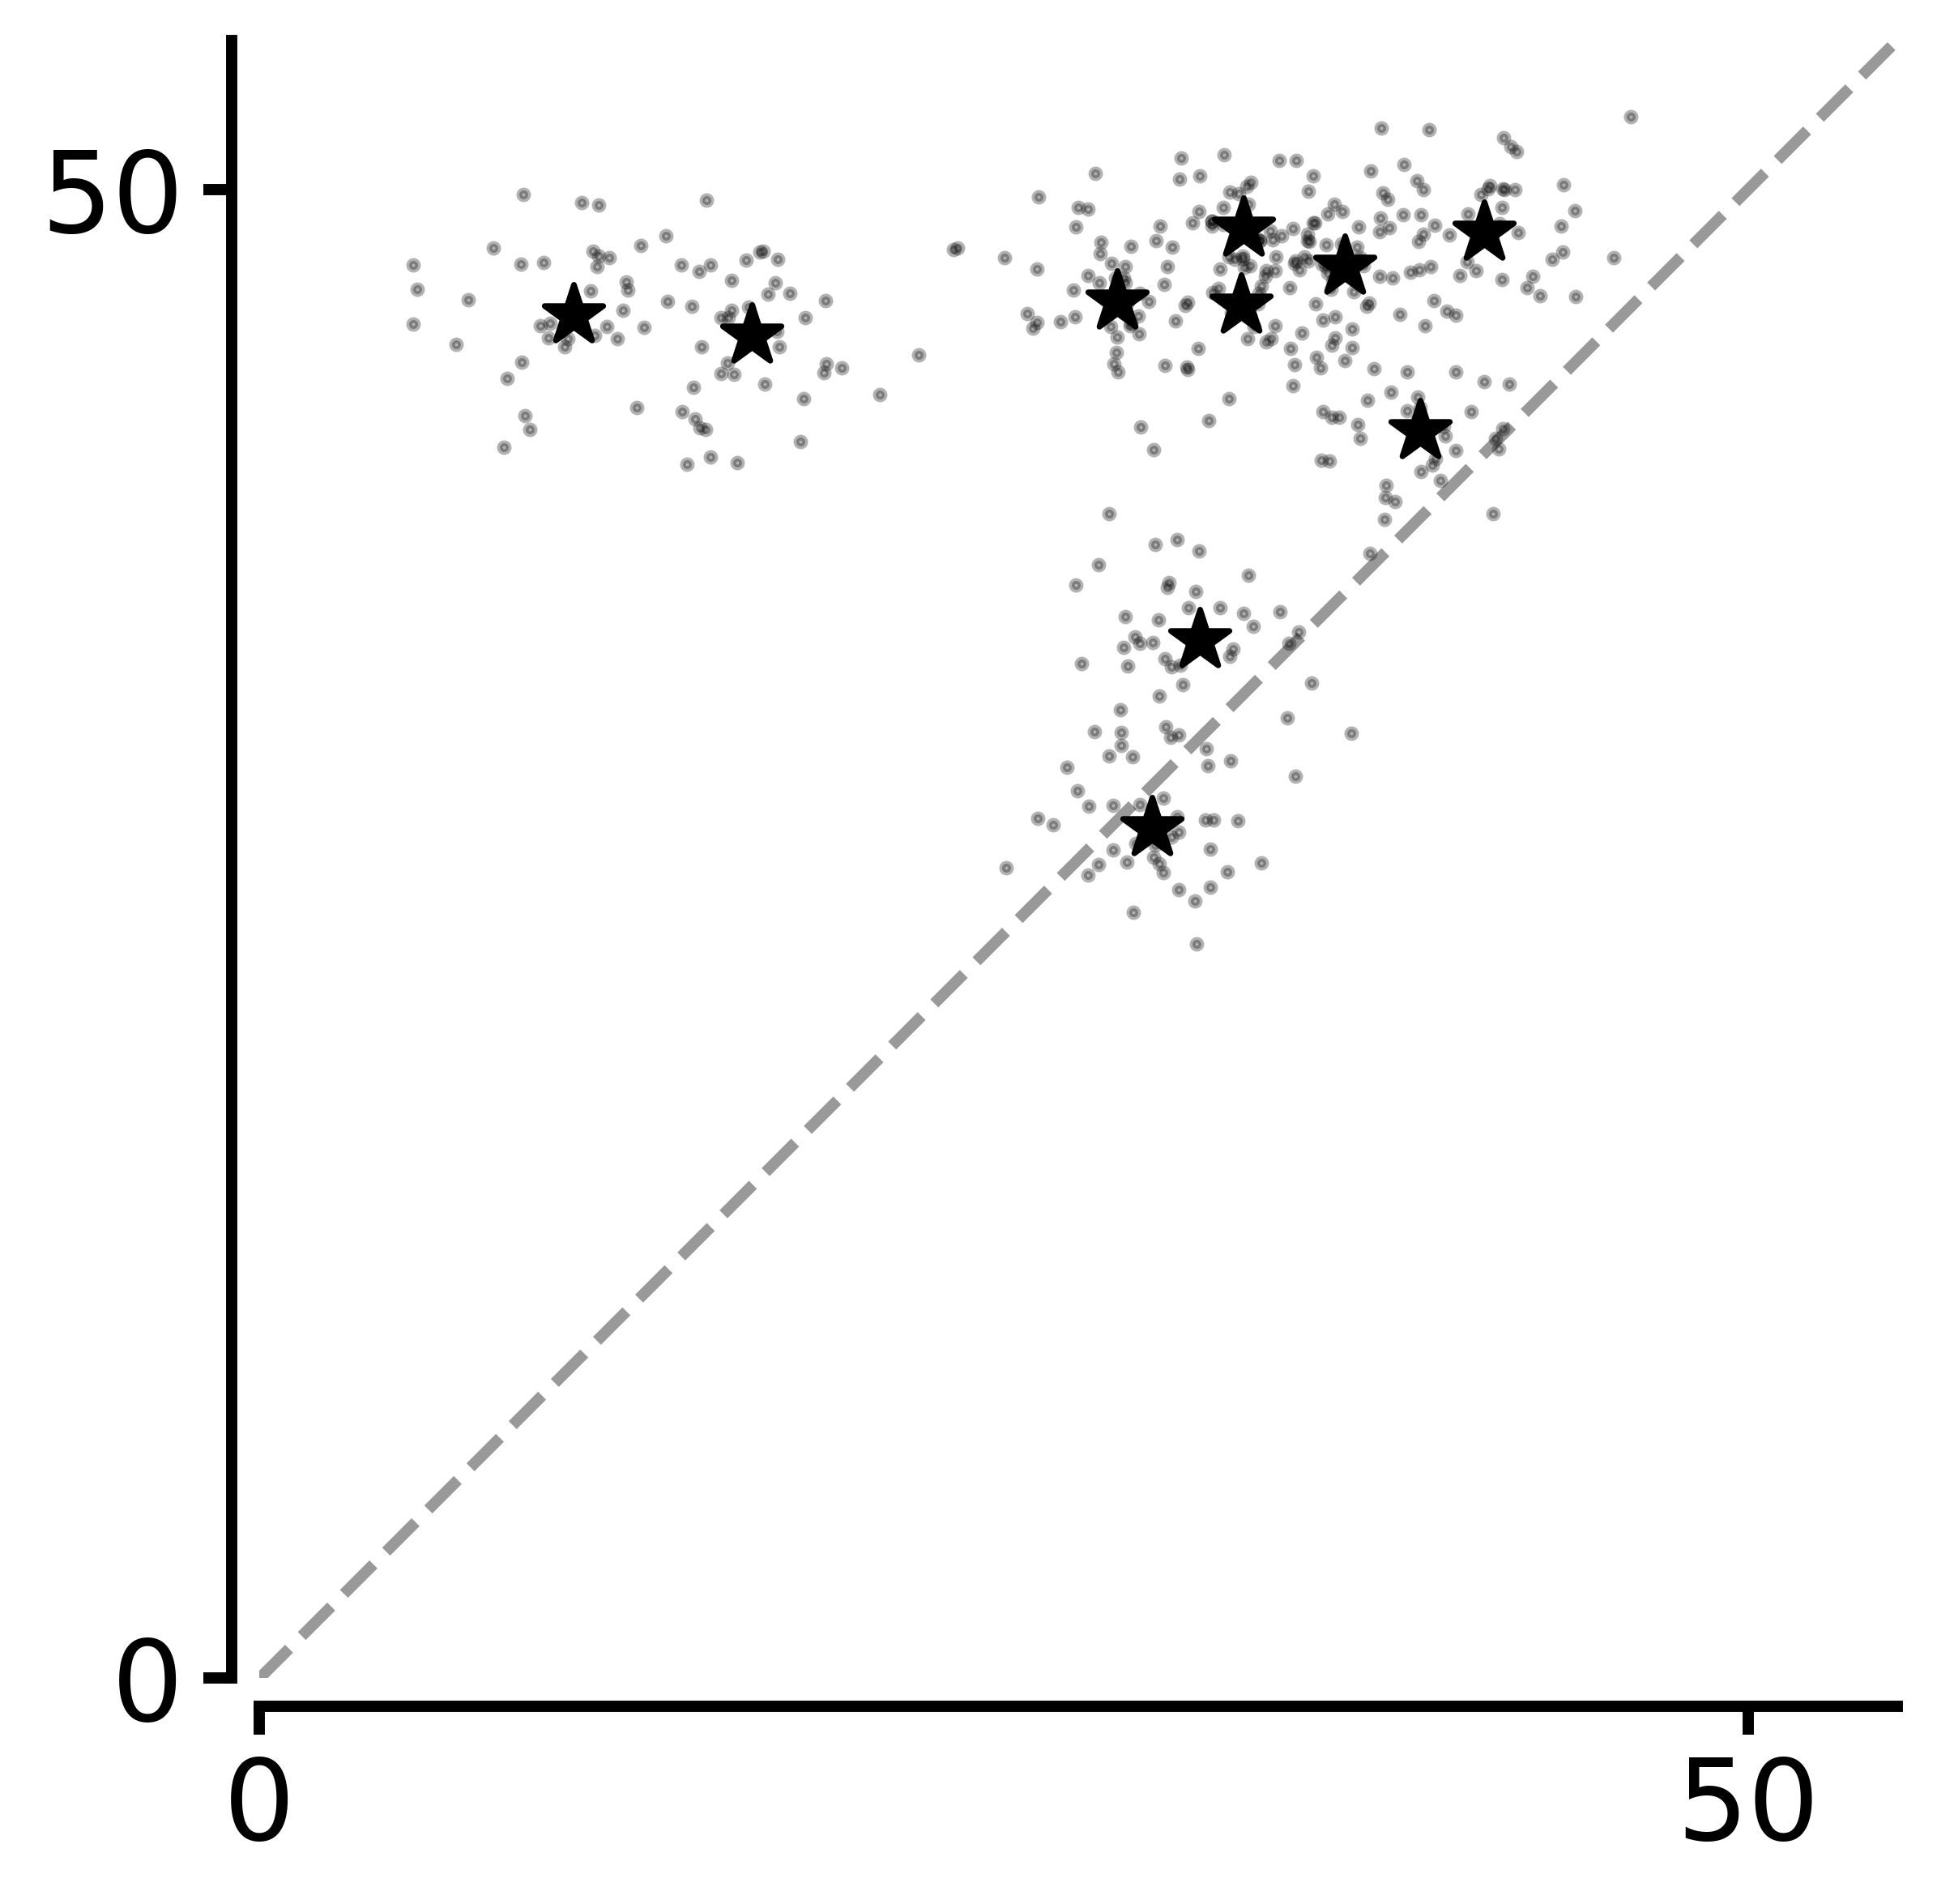

In [57]:
fig, ax = plt.subplots(dpi=500)
ax.plot([0, xlim], [0, ylim], color='black', linestyle='--', linewidth=2, alpha=0.4)
x = all_mei_rates + rng.normal(0, noise, len(all_mei_rates))
y = all_completing_rates + rng.normal(0, noise, len(all_completing_rates))
ax.scatter(
    x,
    y,
    marker=".",
    s=dot_size,
    color="black",
    alpha=dot_alpha
)
ax.scatter(
    all_mei_means,
    all_completing_means,
    marker="*",
    s=star_size,
    color="black",
)
# draw a regression line
# m, b = np.polyfit(all_mei_means, all_completing_means, 1)
# x_ = np.linspace(0, 50, 55)
# y_ = m * x_ + b
# ax.plot(x_, y_, color='black', linestyle='-', linewidth=1)
# ax.plot(, color='gray', linestyle='--')
ax.set_xlim(0, xlim)
ax.set_ylim(0, ylim)
ax.set_xticks([0, last_xtick])
ax.set_yticks([0, last_ytick])
ax.tick_params(axis="both", which="major", labelsize=labelsize, width=2, length=5)
# draw diagonal line
# make square
ax.set_box_aspect(1)
# ax.set_xlabel("Responses to MEI", fontsize=20)
# ax.set_ylabel("Responses to CI", fontsize=20)
ax.spines[['left', 'bottom']].set_linewidth(2)

sns.despine(ax=ax, offset=5)
fig.tight_layout()
fig.savefig("mei_vs_completing.pdf", transparent=True)


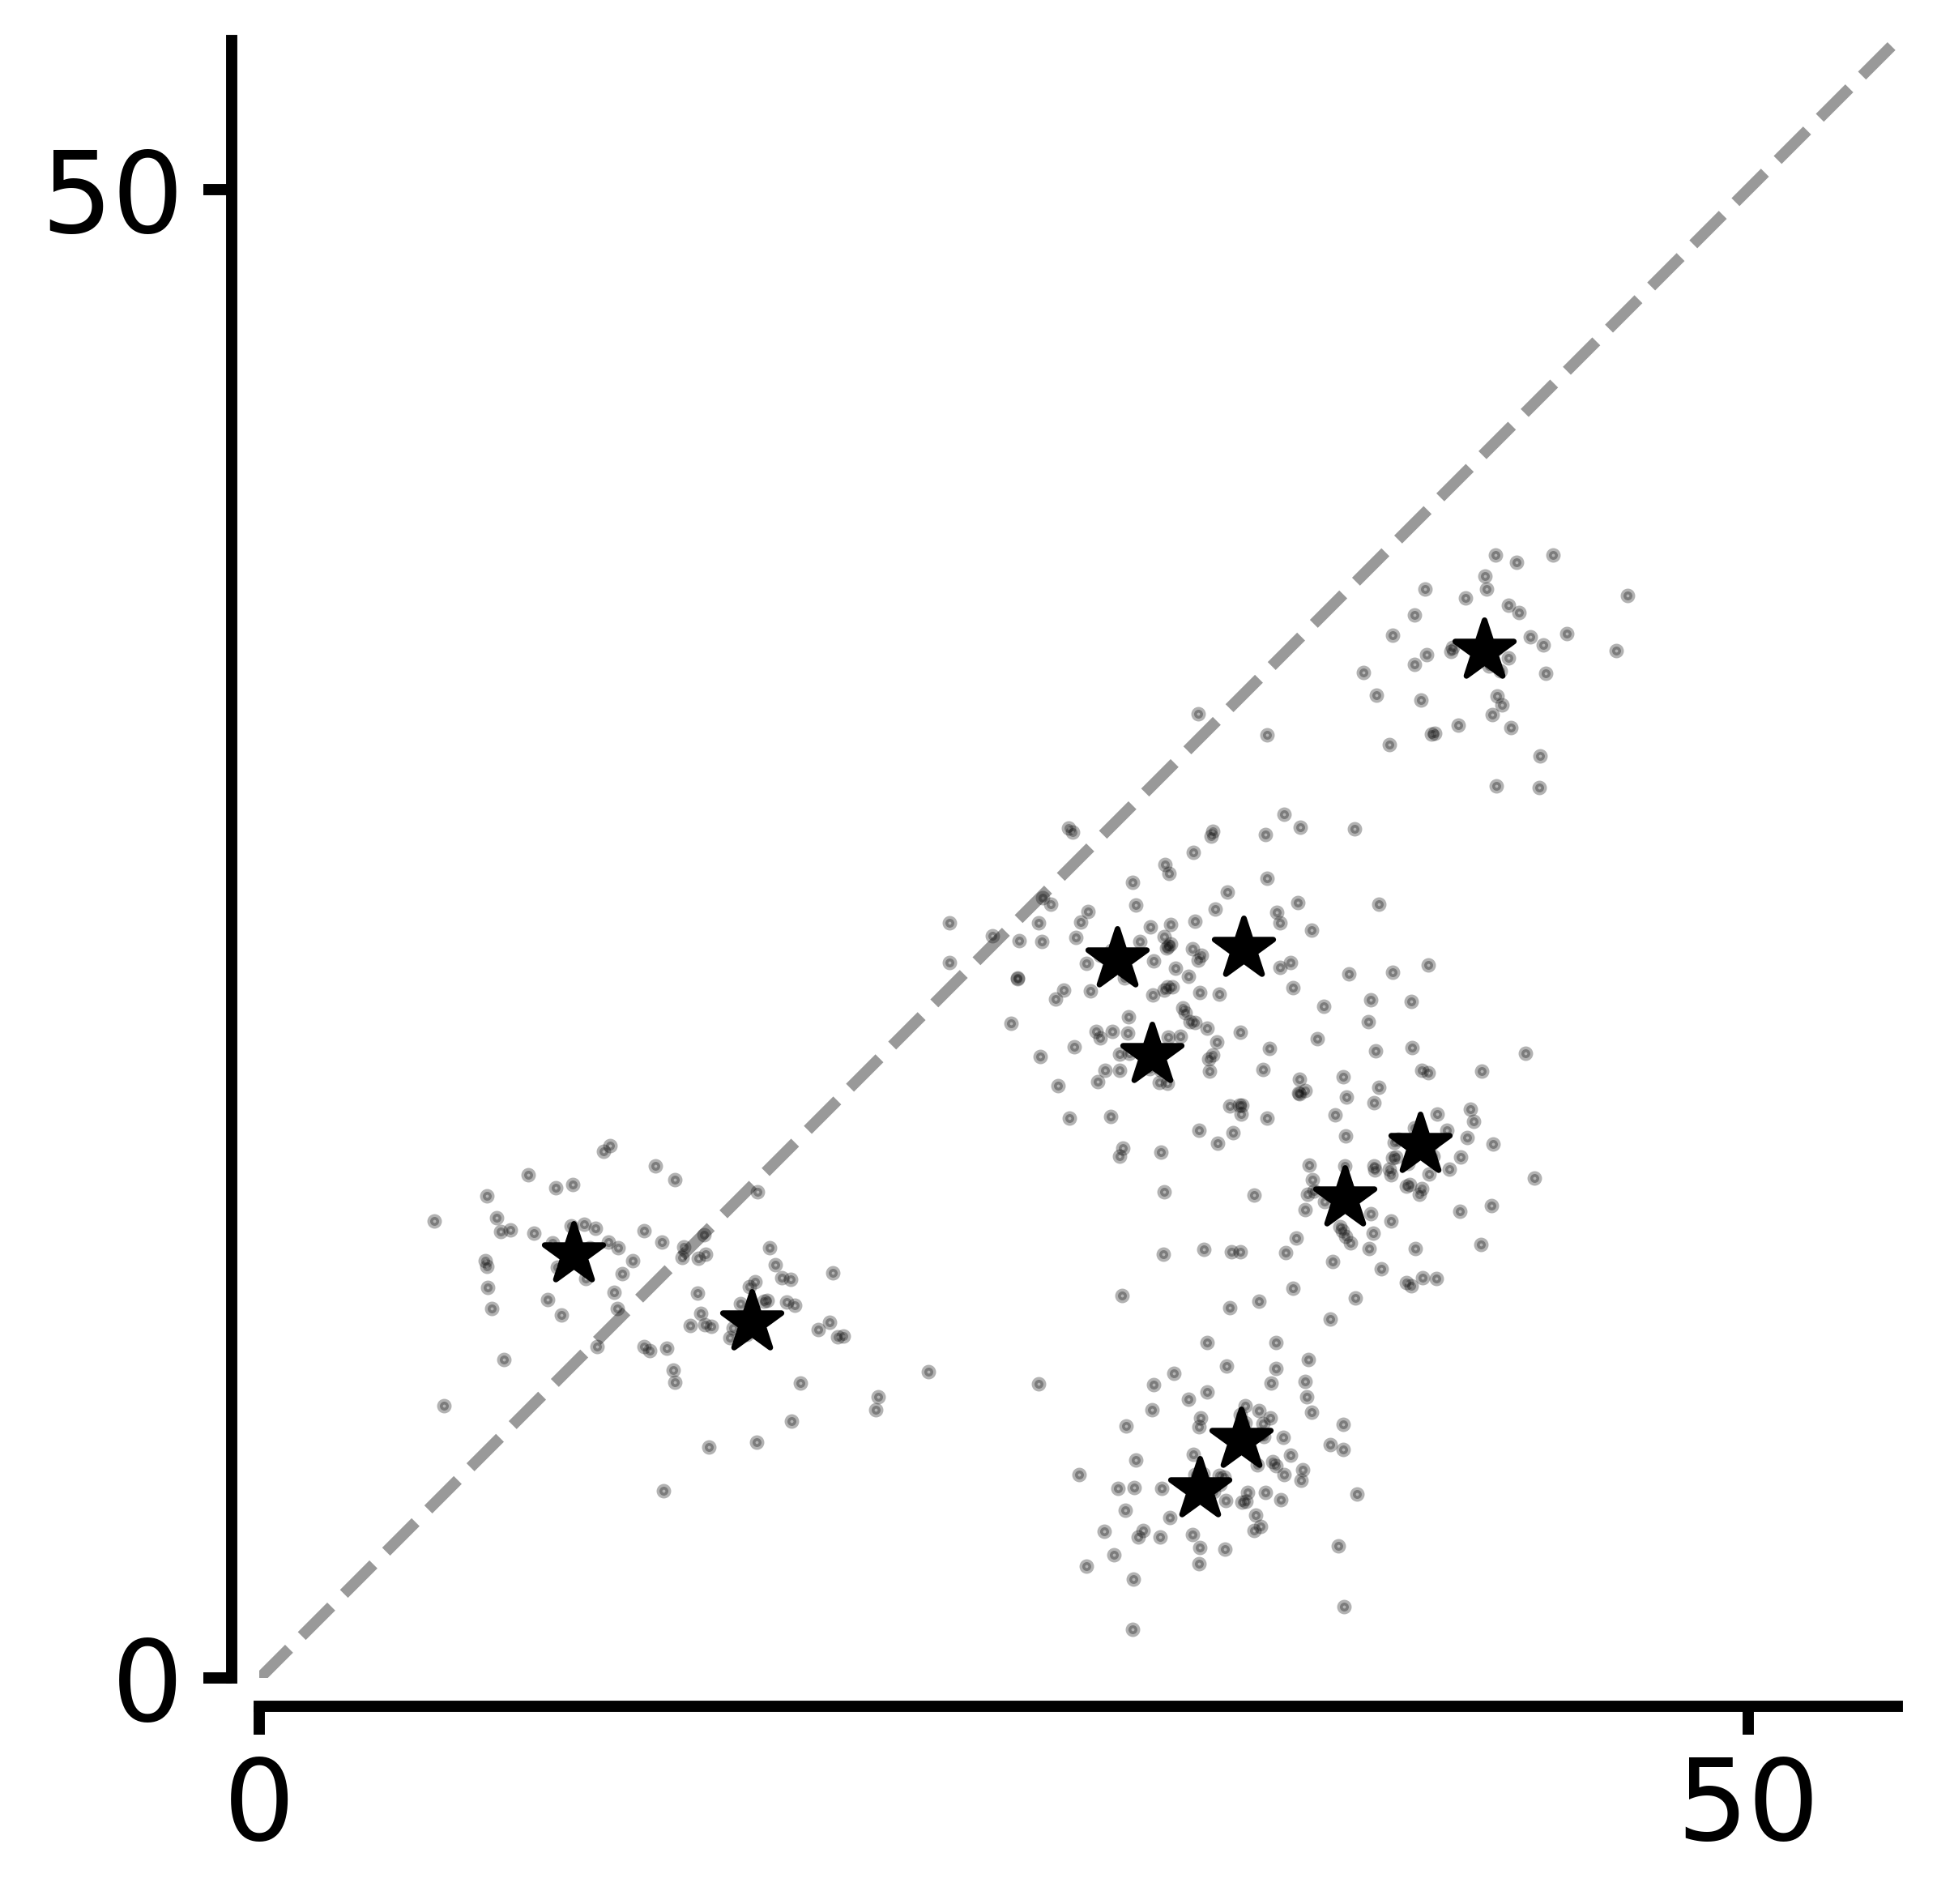

In [58]:
fig, ax = plt.subplots(dpi=500)
ax.plot([0, xlim], [0, ylim], color="black", linestyle="--", linewidth=2, alpha=0.4)
x = all_mei_rates + rng.normal(0, noise, len(all_mei_rates))
y = all_disrupting_1_rates + rng.normal(0, noise, len(all_completing_rates))
ax.scatter(x, y, marker=".", s=dot_size, color="black", alpha=dot_alpha)
ax.scatter(
    all_mei_means,
    all_disrupting_1_means,
    marker="*",
    s=star_size,
    color="black",
)
# draw a regression line
# m, b = np.polyfit(all_mei_means, all_completing_means, 1)
# x_ = np.linspace(0, 50, 55)
# y_ = m * x_ + b
# ax.plot(x_, y_, color='black', linestyle='-', linewidth=1)
# ax.plot(, color='gray', linestyle='--')
ax.set_xlim(0, xlim)
ax.set_ylim(0, ylim)
ax.set_xticks([0, last_xtick])
ax.set_yticks([0, last_ytick])
ax.tick_params(axis="both", which="major", labelsize=labelsize, width=2, length=5)
# draw diagonal line
# make square
ax.set_box_aspect(1)
# ax.set_xlabel("Responses to MEI", fontsize=20)
# ax.set_ylabel("Responses to DI1", fontsize=20)
ax.spines[["left", "bottom"]].set_linewidth(2)

sns.despine(ax=ax, offset=5)
fig.tight_layout()
fig.savefig("mei_vs_disrupting_1.pdf", transparent=True)

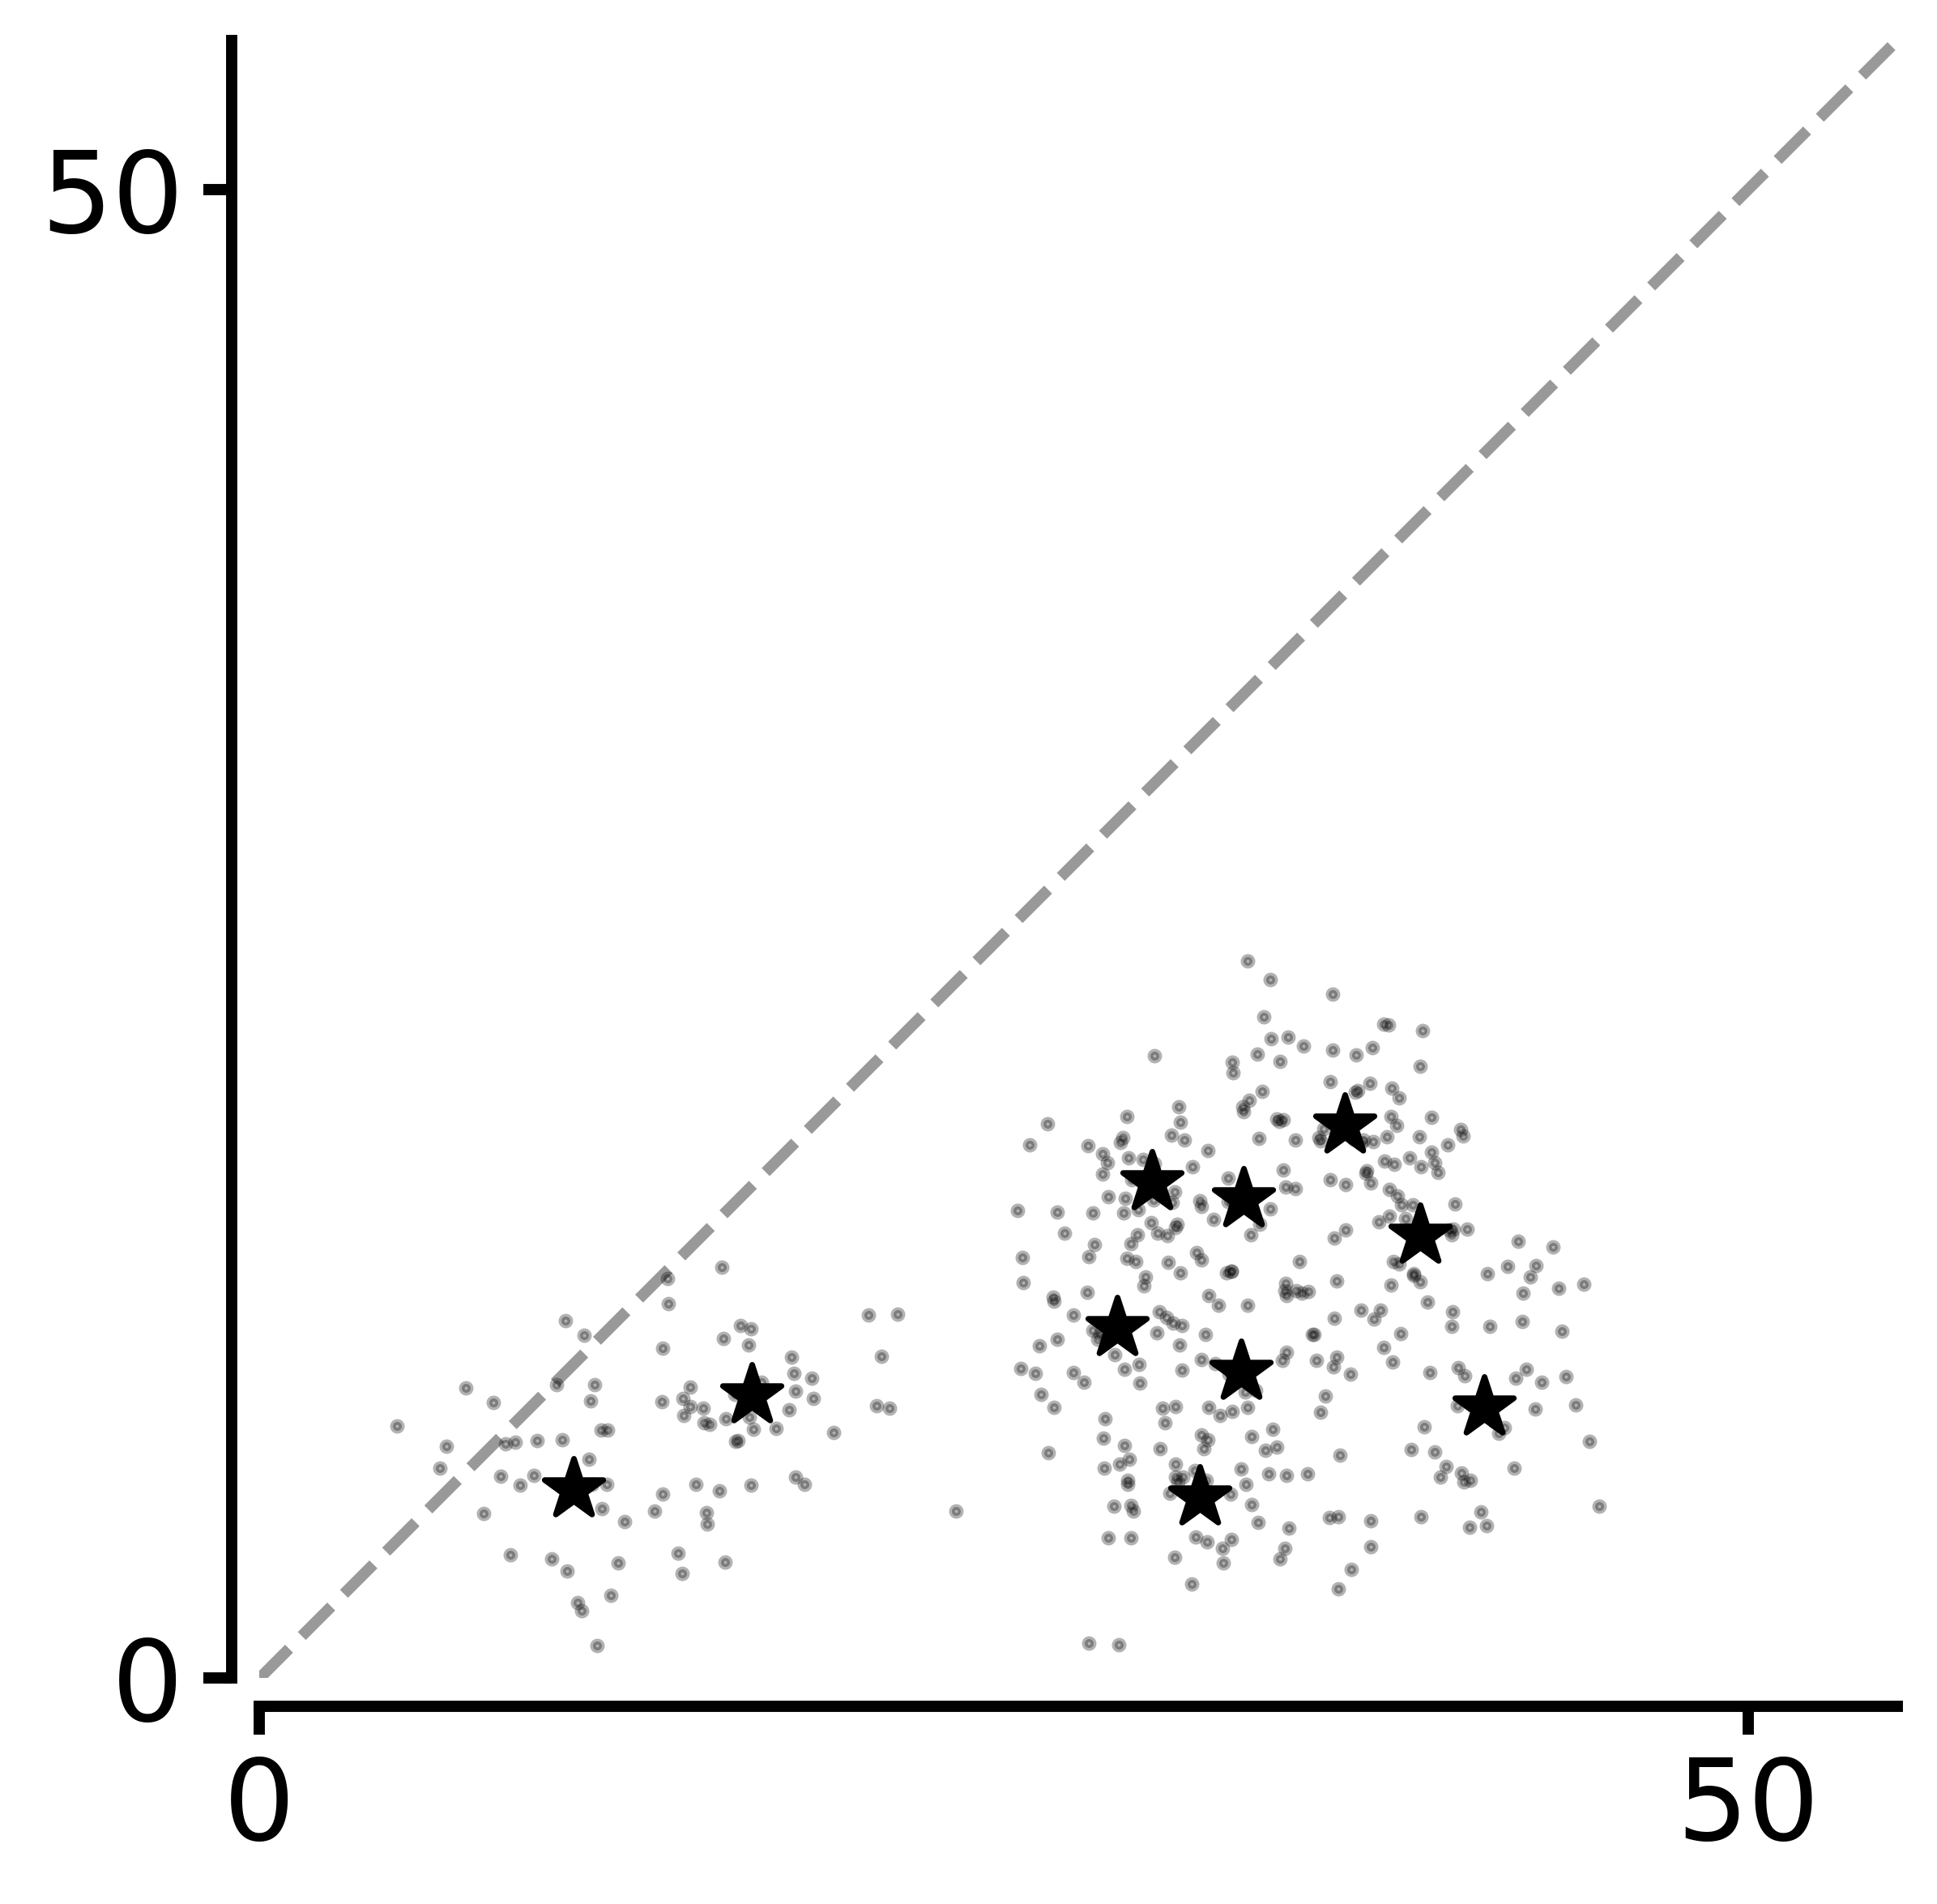

In [59]:
fig, ax = plt.subplots(dpi=500)
ax.plot([0, xlim], [0, ylim], color="black", linestyle="--", linewidth=2, alpha=0.4)
x = all_mei_rates + rng.normal(0, noise, len(all_mei_rates))
y = all_disrupting_2_rates + rng.normal(0, noise, len(all_completing_rates))
ax.scatter(x, y, marker=".", s=dot_size, color="black", alpha=dot_alpha)
ax.scatter(
    all_mei_means,
    all_disrupting_2_means,
    marker="*",
    s=star_size,
    color="black",
)
# draw a regression line
# m, b = np.polyfit(all_mei_means, all_completing_means, 1)
# x_ = np.linspace(0, 50, 55)
# y_ = m * x_ + b
# ax.plot(x_, y_, color='black', linestyle='-', linewidth=1)
# ax.plot(, color='gray', linestyle='--')
ax.set_xlim(0, xlim)
ax.set_ylim(0, ylim)
ax.set_xticks([0, last_xtick])
ax.set_yticks([0, last_ytick])
ax.tick_params(axis="both", which="major", labelsize=labelsize, width=2, length=5)
# draw diagonal line
# make square
ax.set_box_aspect(1)
# ax.set_xlabel("Responses to MEI", fontsize=20)
# ax.set_ylabel("Responses to DI2", fontsize=20)
ax.spines[["left", "bottom"]].set_linewidth(2)

sns.despine(ax=ax, offset=5)
fig.tight_layout()
fig.savefig("mei_vs_disrupting_2.pdf", transparent=True)